### 1. Cloning Model and importing libraries

In [16]:
# from google.colab import drive
# drive.mount('/content/gdrive')
!git clone https://github.com/AshishJangra27/Face-Generator-with-GAN
!git clone https://github.com/AshishJangra27/Gender-Style-Transfer.git

fatal: destination path 'Face-Generator-with-GAN' already exists and is not an empty directory.
fatal: destination path 'Gender-Style-Transfer' already exists and is not an empty directory.


In [17]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

### 2. Loading the Generator

In [18]:
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
generator = tf.keras.models.load_model('/content/Face-Generator-with-GAN/generator_700.h5', compile=False)

### 3. Generating some images

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

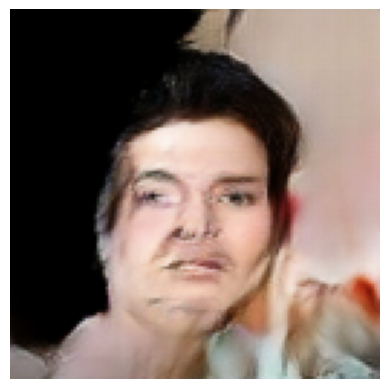

In [19]:
noise = tf.random.normal([1, 100])
# noise += .5

with tf.device('/CPU:0'):
    generated_images = generator(noise, training=False)

generated_images = (generated_images + 1) / 2.0

plt.imshow(generated_images[0])
plt.axis('off')

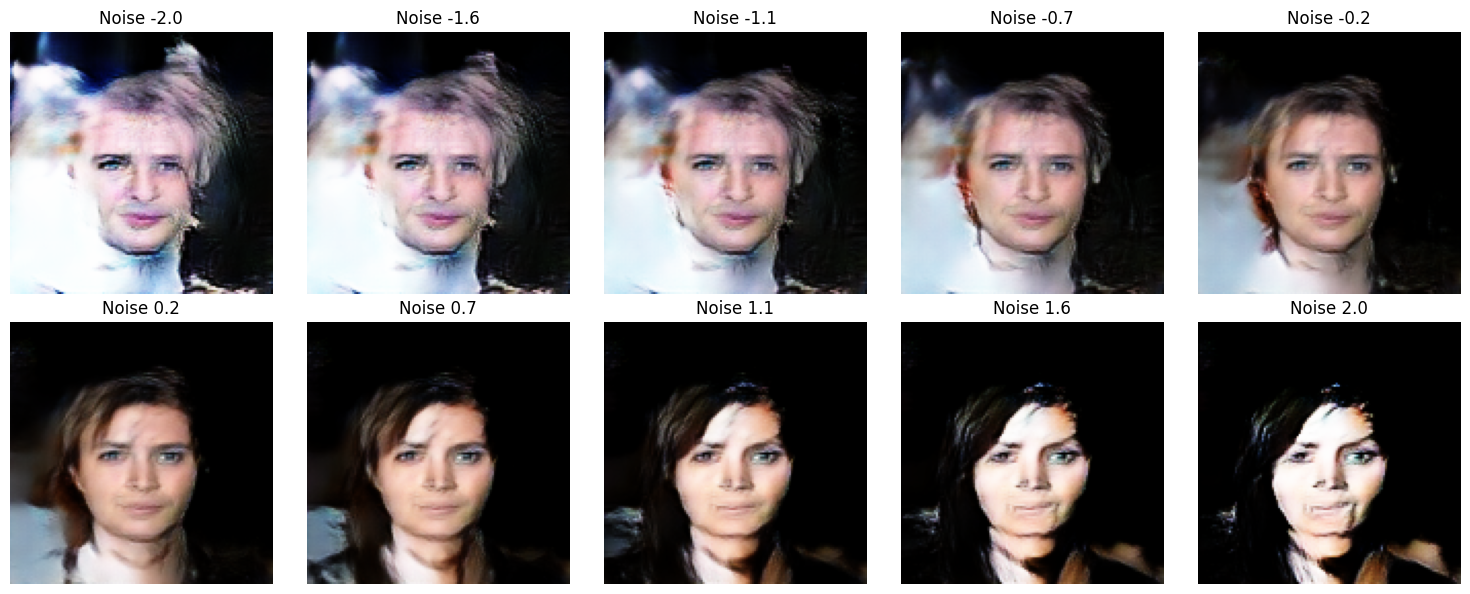

In [20]:
def generate_variations(model, noise_dim=100, num_variations=10):

    base_noise = tf.random.normal([1, noise_dim])

    noise_modifications = np.linspace(-2, 2, num_variations)

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))  # 2 rows, 5 columns

    for i, noise_offset in enumerate(noise_modifications):
        variation_noise = base_noise + noise_offset

        with tf.device('/CPU:0'):
            generated_image = model(variation_noise, training=False)

        generated_image = (generated_image + 1) / 2.0

        ax = axes[i // 5, i % 5]
        ax.imshow(generated_image[0])
        ax.axis('off')
        ax.set_title(f"Noise {noise_offset:.1f}")

    plt.tight_layout()
    plt.show()

# Generate and display variations
generate_variations(generator)

### 4. Getting gender vector

In [21]:
import ast

male_vec   = pd.read_csv('/content/Gender-Style-Transfer/male_images_data.csv')['noise_vector']
female_vec = pd.read_csv('/content/Gender-Style-Transfer/female_images_data.csv')['noise_vector']

male_vec = np.array([np.array(ast.literal_eval(vec)) for vec in male_vec])
female_vec = np.array([np.array(ast.literal_eval(vec)) for vec in female_vec])

avg_male_vec = np.mean(male_vec, axis=0)
avg_female_vec = np.mean(female_vec, axis=0)
gender_vector = avg_male_vec - avg_female_vec

print("Average Noise Vector (Male):", avg_male_vec)
print("Average Noise Vector (Female):", avg_female_vec)
print("Gender Vector:", gender_vector)

Average Noise Vector (Male): [[-0.03971258 -0.06965943  0.00356897  0.00640304 -0.21249051 -0.09229452
  -0.04259478  0.07553213  0.22617031 -0.17790783  0.28319609  0.10857499
  -0.03823045 -0.31559354 -0.24628071  0.03348317 -0.22993282  0.04861173
  -0.00585154 -0.08720009 -0.08516999 -0.18133756  0.11148302  0.08788833
   0.15843068  0.04221111 -0.05985005  0.17341407  0.16704901 -0.0814995
   0.01657156  0.12935034 -0.11328441 -0.25267418  0.13558398 -0.28655694
   0.33639507  0.01914521  0.17857791  0.19870061 -0.05791203 -0.10840931
  -0.18405729 -0.01757116 -0.16858907  0.15148676  0.00552569  0.06799198
  -0.05409135  0.03634662 -0.11298827  0.19775391  0.03667391  0.12799914
  -0.12258946  0.03495421 -0.03805487  0.1108679  -0.20347688 -0.0874216
  -0.00659081 -0.14985104  0.12018388 -0.08695146  0.10339797  0.33737177
  -0.07528706 -0.04015739  0.11054354  0.0293739  -0.09600242  0.19884786
   0.14673617 -0.00366311 -0.1227755  -0.04305195 -0.14596911 -0.08136474
  -0.010025

### 5. Generating 10 diiferent variations of images

In [22]:
def generate(noise):
    return (generator(noise, training=False) + 1) / 2.0

# Generate 10 different noise vectors
noises = tf.random.normal([10, 100])
modifications = [2.5, 2, 1.5, 1, 0.5, 0, -0.5, -1, -1.5, -2,-2.5]

fig, axes = plt.subplots(10, 11, figsize=(15, 15))

for row, noise in enumerate(noises):
    for col, mod in enumerate(modifications):
        axes[row, col].imshow(generate(noise + mod * gender_vector)[0])
        axes[row, col].axis("off")

plt.subplots_adjust(wspace=0, hspace=0)
plt.tight_layout(pad=0)
plt.show()

Output hidden; open in https://colab.research.google.com to view.